# Fake and Real News Analysis
## Project Overview

This notebook provides an in-depth analysis of the *Fake and Real News* dataset available on [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset). The primary objective is to build an end-to-end Natural Language Processing (NLP) pipeline to solve a **supervised binary classification** problem on textual data.

The project covers the entire machine learning workflow:
- **Data Cleaning & Normalization**: Refining raw text to remove noise.
- **Exploratory Data Analysis (EDA)**: Identifying linguistic patterns and class distributions.
- **Feature Extraction**: Converting text into numerical representations using **TF-IDF**.
- **Model Benchmarking**: Implementing, tuning, and comparing several classification models (e.g., LinearSVC, XGBoost, Decision Trees) to identify the most robust solution for misinformation detection.

## Text Preprocessing & Normalization
Before applying any classification algorithm, it is essential to standardize the textual data. Raw text contains noise (punctuation, HTML tags, varied capitalization) that can negatively affect model performance.

The following **NLP pipeline** was implemented to normalize the dataset:
- **Noise Removal**: Eliminating URLs, HTML tags, and specific Regex patterns (e.g., removing "Reuters" to prevent **data leakage**).
- **Lowercasing**: Converting all text to lowercase to ensure the model treats "Truth" and "truth" as the same token.
- **Lemmatization**: Reducing words to their base or dictionary form (e.g., "running" to "run") using the WordNet Lemmatizer.
- **Stopword Removal**: Filtering out common words (e.g., "the", "is", "at") that carry little semantic value.
- **Punctuation & Symbol Cleaning**: Stripping non-alphanumeric characters to focus on core linguistic content.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manue\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manue\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# dataset import
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

In [3]:
# binary target label (0: Fake, 1: True)
fake["label"] = 0
true["label"] = 1

### Dataset Merging & Randomization
To prepare the final dataset for training, we concatenate the two sources. 
A crucial step here is **shuffling**: since the original files are ordered by class, randomizing the rows ensures that the training and validation sets will have a representative distribution of both categories, preventing the model from learning order-based patterns.

In [4]:
# data merging and randomizaztion
df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


### Feature Engineering: Content Concatenation
The final input for the machine learning models is created by concatenating the **article titles** and the **body text**. 

This approach ensures that the models can leverage linguistic patterns from both the headlines (which often contain sensationalist markers in fake news) and the detailed content.

**Technical Note**: Concatenation is performed *after* the individual column preprocessing. This modular approach was chosen to:
1. Maintain data integrity for granular text analysis (e.g., comparing title vs. body lengths).
2. Facilitate manual inspection of processed tokens for each field before merging them into a single feature vector.

In [5]:
# columns containing news' title and body
df["title_analysis"] = df["clean_title"] = df["title"]
df["text_analysis"] = df["clean_text"] = df["text"]
cols = ["title_analysis", "text_analysis"]

### Text Cleaning and Normalization
In this phase, we perform deep cleaning of the corpus to ensure the models learn from actual content rather than metadata or formatting artifacts.

#### Pattern Removal (Regex-based)
We use **Regular Expressions (Regex)** to eliminate specific text patterns that could lead to **data leakage**:
* **Source Attribution**: Real news often contains signatures like *"CITY (Reuters) -"*. We remove these to prevent the model from identifying the source instead of the news content.
* **Tag Cleaning**: We remove uppercase tags in brackets (e.g., *[VIDEO]*, *(PICTURE)*) which are frequently found in fake news headlines but provide no semantic value for classification.

In [6]:
# regex-based removal of visible patterns
# remove the 'CITY (Reuters) -' pattern from real news
df["clean_text"] = df["clean_text"].str.replace(r'\b[A-Z][^\)]*\(Reuters\)', '', regex=True) 

# remove remaining instances of 'Reuters' (case insensitive)
df["clean_text"] = df["clean_text"].str.replace(r'\bReuters\b', '', regex=True, flags=re.IGNORECASE) 

# remove uppercase words in brackets (e.g., (VIDEO), [PICTURE]) typical of fake news headlines
df['clean_title'] = df['clean_title'].str.replace(r'[\(\[]( [A-Z\s]+)[\)\]]', '', regex=True)

### Case Normalization
Finally, we convert all text to **lowercase**. This step is fundamental for reducing the vocabulary size and ensuring that the model treats identical words (e.g., "News", "NEWS", and "news") as the same entity, preventing unnecessary fragmentation of the TF-IDF feature space.

In [7]:
# lowercasing
df["clean_title"] = df["clean_title"].str.lower()
df["clean_text"] = df["clean_text"].str.lower()
df[cols] = df[cols].apply(lambda x: x.str.lower())

### Text Cleaning: URL and HTML Removal
To eliminate non-textual **noise** from the dataset, we apply two cleaning steps using Regular Expressions:
* **URL Removal**: We strip all web addresses (*http*, *https*, *www*) to prevent unique strings from distorting the feature space.
* **HTML Stripping**: We remove residual tags (e.g., `<div>`, `<p>`) to ensure that only raw news content is analyzed.

These steps are essential to ensure the **TF-IDF vectorizer** focuses exclusively on linguistic patterns rather than technical artifacts or web formatting.

In [8]:
# URL removal function
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
# apply URL removal to modeling and analysis columns
df["clean_title"] = df["clean_title"].apply(lambda text : remove_urls(text))
df["clean_text"] = df["clean_text"].apply(lambda text : remove_urls(text))
df[cols] = df[cols].map(remove_urls)

In [9]:
# HTML tags removal function
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)
# apply HTML tags removal
df["clean_title"] = df["clean_title"].apply(lambda text : remove_html(text))
df["clean_text"] = df["clean_text"].apply(lambda text : remove_html(text))
df[cols] = df[cols].map(remove_html)

### WordNet Lemmatization
We apply **Lemmatization** using the WordNet library to reduce words to their dictionary root (e.g., "running" becomes "run"). Unlike simple stemming, lemmatization considers the morphological analysis of words, effectively consolidating different inflections of the same term. This significantly reduces the dimensionality of the **TF-IDF matrix** without losing the semantic essence of the text.

In [10]:
# WordNet Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])
# apply lemmatization
df["clean_title"] = df["clean_title"].apply(lambda text : lemmatize_words(text))
df["clean_text"] = df["clean_text"].apply(lambda text : lemmatize_words(text))
df[cols] = df[cols].map(lemmatize_words)

### Stopword Removal
We filter out **stopwords** using the NLTK English corpus. Common words like "the", "is", and "at" are removed because they carry little semantic weight and appear frequently in almost all documents. Eliminating them allows the model to prioritize meaningful keywords that better distinguish between real and fake news content.

In [11]:
# stopword removal using NLTK English corpus
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
# apply stopword filtering
df["clean_title"] = df["clean_title"].apply(lambda text : remove_stopwords(text))
df["clean_text"] = df["clean_text"].apply(lambda text : remove_stopwords(text))
df[cols] = df[cols].map(remove_stopwords)

### Punctuation and Symbol Removal
Finally, we strip all **non-alphanumeric characters** (punctuation, symbols, and special characters) using Regular Expressions. Removing these elements prevents the vectorizer from creating unnecessary features for symbols like commas or exclamation marks, further refining the dataset to contain only pure, meaningful words.

In [12]:
# symbol removal: strip any non-alphanumeric characters
df["clean_title"] = df["clean_title"].str.replace(r"[^\w\s]", "", regex=True)
df["clean_text"] = df["clean_text"].str.replace(r"[^\w\s]", "", regex=True)
df[cols] = df[cols].apply(lambda x : x.str.replace(r"[^\w\s]", "", regex=True))

### Final Cleaning & Feature Merging
After removing non-alphanumeric characters, we concatenate the processed titles and bodies. This creates a unified textual representation for each record, ready to be vectorized.

In [13]:
# concatenate title and body for Machine Learning algorithms
df["processed"] = df["clean_title"] + " " + df["clean_text"]

### Data Integrity: handling duplicates and missing values
To ensure the robustness of our models, we perform a final check for **missing values (NAs)** and **duplicate entries**. 
Duplicate records can lead to an artificial inflation of accuracy if the same news appears in both training and test sets. 
Cleaning these ensures that the model generalizes on unique linguistic patterns.

In [14]:
# initial check for duplicates and missing values
print(f"Duplicate values: {df.duplicated().sum()}")
print(f"NA values: \n{df.isna().sum()}")

# data cleaning: remove duplicates and drop any rows with missing values
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

# verification after cleaning
print(f"*** Post-cleaning verification ***")
print(f"Duplicate values: {df.duplicated().sum()}")
print(f"NA values: \n{df.isna().sum()}")

Duplicate values: 209
NA values: 
title             0
text              0
subject           0
date              0
label             0
title_analysis    0
clean_title       0
text_analysis     0
clean_text        0
processed         0
dtype: int64
*** Post-cleaning verification ***
Duplicate values: 0
NA values: 
title             0
text              0
subject           0
date              0
label             0
title_analysis    0
clean_title       0
text_analysis     0
clean_text        0
processed         0
dtype: int64


In [15]:
# data after preprocessing
df.head()

,title,text,subject,date,label,title_analysis,clean_title,text_analysis,clean_text,processed
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,ben stein call 9th circuit court committed cou...,ben stein call 9th circuit court committed cou...,21st century wire say ben stein reputable prof...,21st century wire say ben stein reputable prof...,ben stein call 9th circuit court committed cou...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,trump drop steve bannon national security council,trump drop steve bannon national security council,washington reuters us president donald trump ...,us president donald trump removed chief strat...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,puerto rico expects us lift jones act shipping...,puerto rico expects us lift jones act shipping...,reuters puerto rico governor ricardo rossello...,puerto rico governor ricardo rossello said w...,puerto rico expects us lift jones act shipping...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,oops trump accidentally confirmed leaked israe...,oops trump accidentally confirmed leaked israe...,monday donald trump embarrassed country accide...,monday donald trump embarrassed country accide...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,donald trump head scotland reopen golf resort,donald trump head scotland reopen golf resort,glasgow scotland reuters us presidential cand...,us presidential candidate go abroad sharpen f...,donald trump head scotland reopen golf resort ...


# Exploratory Data Analysis (EDA): Statistical and Linguistic Patterns
In this section, we leverage the previously defined preprocessing functions and custom scripts to analyze meaningful patterns within the text. 
Understanding the statistical differences between Fake and Real news is crucial for identifying which features will be most discriminative for our machine learning models.

The analysis follows a structured approach across four main pillars:

1. **Class Distribution**: Verifying the balance between Fake and Real news to ensure a fair evaluation and prevent majority-class bias.
2. **Punctuation Analysis**: Investigating the frequency of exclamation marks, question marks, ellipses, and quotes as potential markers of sensationalism and clickbait.
3. **Lexical Frequency**: Identifying the most frequent words to uncover recurring thematic patterns and common topics in both categories.
4. **Structural Distribution**: Examining the length (word count) of titles and article bodies to identify structural trends and significant outliers that distinguish official reports from misinformation.

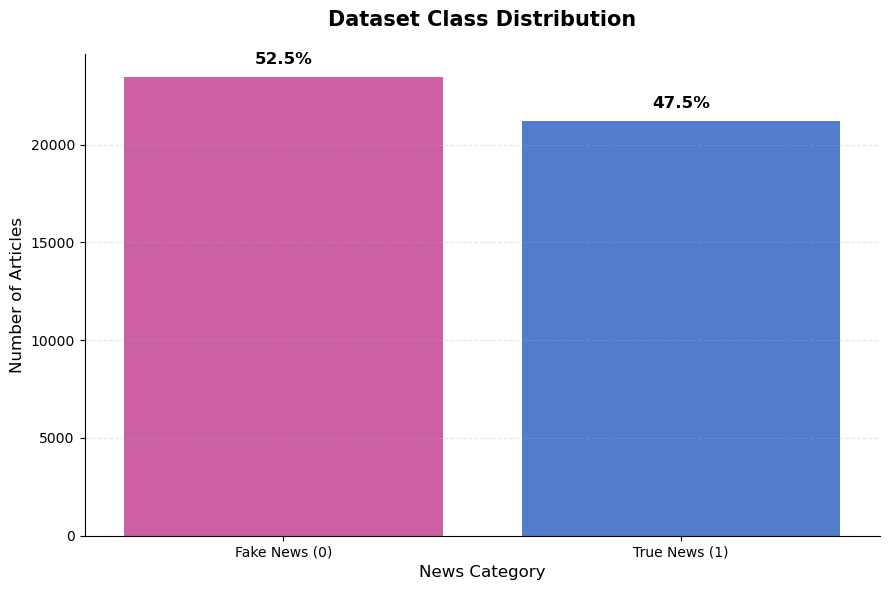

In [16]:
# 1. custom color palette definition
my_palette = {0: "#de4ea7", 1: "#3e77e1"}

plt.figure(figsize=(9, 6))

# 2. plot creation using seaborn
# using the specific palette for consistency across the entire nlp pipeline
ax = sns.countplot(x='label', data=df, palette=my_palette, hue='label', legend=False)

# 3. styling and labels
plt.title('Dataset Class Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks([0, 1], ['Fake News (0)', 'True News (1)'])

# 4. percentage annotation for better readability
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', 
                fontsize=12, fontweight='bold', xytext=(0, 7), 
                textcoords='offset points')

# aesthetic adjustments
sns.despine() # removing top and right spines to avoid sovrapposition with percentages
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

> **Technical Insight**: The dataset shows an optimal balance between classes (~47.7% Fake vs. ~52.3% True). This statistical symmetry allows us to proceed with model training without the risk of majority-class bias, avoiding the need for oversampling or undersampling strategies.

### Punctuation Pattern Recognition
Beyond the words themselves, the use of punctuation can serve as a stylistic fingerprint. We use regular expressions to isolate and count specific marks, investigating whether their frequency correlates with **clickbait** strategies. 

For instance, an excessive use of exclamation points (`!`) and question marks (`?`) is often a hallmark of sensationalist headlines designed to trigger emotional responses, a common trait in non-verified information.

In [17]:
# punctuation extraction and filtering
def punct_frequency(dataframe, top_pos):
    cnt = Counter()
    for text in dataframe.values:
        # all_punct = re.findall(r"!|\?|\.{3}|…|[\"«»‹›„“”‘’‚《》〈〉]", str(text)) # variant with specific regex
        all_punct = re.findall(r"[^\w\s]", str(text))
        for punct in all_punct:
            cnt[punct] += 1

    dict = {}

    for punct, count in cnt.most_common(top_pos):
        dict[punct] = count
    return dict

### Data Cleaning for Punctuation Analysis
To ensure the accuracy of our punctuation counts, we must first remove **URLs and hypertext markers**. Web addresses contain numerous symbols (periods, slashes, colons) that do not represent stylistic choices or grammatical structure. 

By stripping these elements, we prevent them from skewing the statistical distribution of our punctuation features, ensuring that our analysis reflects the actual writing style of the news articles.

In [18]:
df["title_punct"] = df["title"].apply(lambda text: remove_html(text)).apply(lambda text: remove_urls(text))
df["text_punct"] = df["text"].apply(lambda text: remove_html(text)).apply(lambda text: remove_urls(text))

### Visualizing Punctuation Bias: Relative Frequency Analysis
To compare the use of punctuation across classes, we calculate the **Relative Frequency** of each mark. This normalization is essential to ensure that differences in the total volume of text between Fake and Real news do not skew the results.

We focus on a side-by-side comparison to highlight which symbols are disproportionately present in one category versus the other, providing a visual confirmation of stylistic biases.

In [19]:
def plot_punct_freq(dict_fake, dict_true, title):
    # punctuation counting
    puncts = list(set(dict_fake.keys()) | set(dict_true.keys()))
    fake_counts = {p: dict_fake.get(p, 0) for p in puncts}
    true_counts = {p: dict_true.get(p, 0) for p in puncts}

    # relative frequencies calculation
    # normalizing by total punctuation count to allow fair comparison
    f_total, t_total = sum(fake_counts.values()), sum(true_counts.values())
    fake_rel = {p: c / f_total for p, c in fake_counts.items() if f_total > 0}
    true_rel = {p: c / t_total for p, c in true_counts.items() if t_total > 0}

    # sorting by combined frequency for better visualization
    combined = {p: fake_rel.get(p, 0) + true_rel.get(p, 0) for p in puncts}
    ordered_puncts = sorted(combined, key=combined.get, reverse=True)

    fake_values = [fake_rel.get(p, 0) for p in ordered_puncts]
    true_values = [true_rel.get(p, 0) for p in ordered_puncts]

    # plotting setup
    x, width = np.arange(len(ordered_puncts)), 0.35
    fig, ax = plt.subplots(figsize=(9, 5))

    # using the project's consistent pink/blue palette
    ax.bar(x - width/2, fake_values, width, label='Fake', color="#de4ea7", alpha=0.9, edgecolor='white')
    ax.bar(x + width/2, true_values, width, label='True', color="#3e77e1", alpha=0.9, edgecolor='white')

    # chart styling and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Frequency')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_puncts, fontsize=12)
    ax.legend()
    ax.yaxis.grid(True, linestyle='--', alpha=0.6) # alpha defines transparency

    plt.tight_layout()
    plt.show()

### Comparative Punctuation Analysis: Titles vs. Article Body
To gain a deeper understanding of the linguistic style, we visualize the most frequent punctuation marks in proportion to the total symbols found in the text. 

This comparative analysis is split into two distinct parts:
1. **Headlines**: To identify potential "clickbait" markers and sensationalist trends in titles.
2. **Article Body**: To examine the overall narrative structure and formal tone of the full reports.

### Quantitative Analysis of Headline Punctuation
In this step, we extract and aggregate the punctuation counts for the top 15 most frequent marks found in the headlines. By splitting the dataset by label, we can isolate the stylistic tendencies of both Fake and Real news categories.

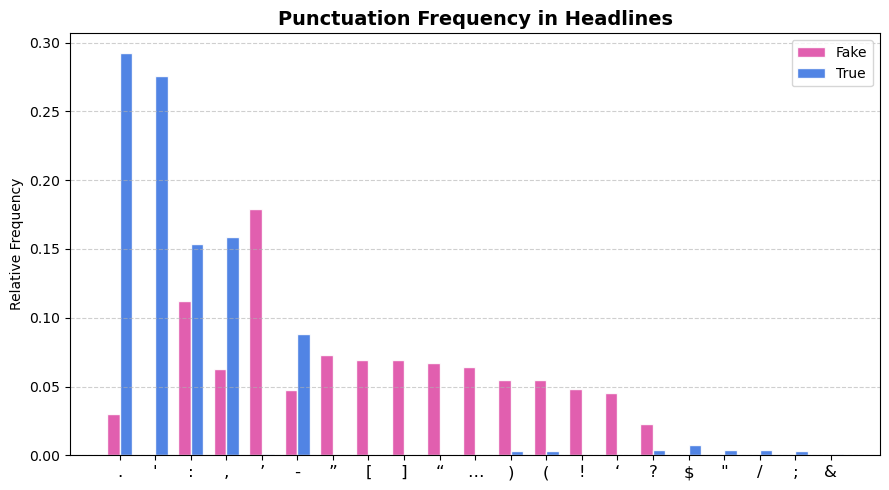

In [20]:
# extracting top 15 punctuation marks for fake news headlines
fake_title_punct = punct_frequency(df[df["label"] == 0]["title_punct"], 15)

# extracting top 15 punctuation marks for real news headlines
true_title_punct = punct_frequency(df[df["label"] == 1]["title_punct"], 15)

# plotting the comparative distribution for headlines
# using international titles for the charts
plot_punct_freq(fake_title_punct, true_title_punct, "Punctuation Frequency in Headlines")

### Quantitative Analysis of Article Body Punctuation
After analyzing the headlines, we extend the same methodology to the full text of the articles. This allows us to verify if the stylistic markers identified in the titles persist throughout the entire narrative or if they are primarily a characteristic of the "hook" (the headline).

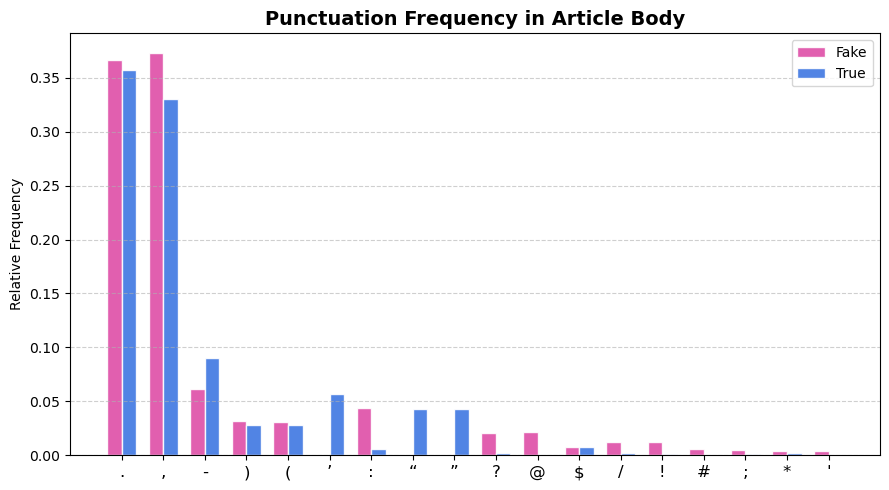

In [21]:
# extracting top 15 punctuation marks for fake news body text
fake_text_punct = punct_frequency(df[df["label"] == 0]["text_punct"], 15)

# extracting top 15 punctuation marks for real news body text
true_text_punct = punct_frequency(df[df["label"] == 1]["text_punct"], 15)

# plotting the comparative distribution for the article body
# analyzing the overall structural and formal tone
plot_punct_freq(fake_text_punct, true_text_punct, "Punctuation Frequency in Article Body")

### Lexical Feature Extraction: Term Frequency Mapping
To identify the most influential words in the dataset, we implement a frequency-counting function using the **Counter** library. This process transforms the unstructured text into a ranked dictionary of terms, providing a quantitative snapshot of the vocabulary used in Fake vs. Real news.

By isolating the most common words, we can detect **thematic clusters** and assess if specific topics are disproportionately associated with one of the two classes.

In [22]:
# the function takes the text and the number of top positions as input
# returns a dictionary containing the word frequencies
def word_frequency(dataframe, top_pos):
    cnt = Counter()
    for text in dataframe.values:
        if isinstance(text, str): # handling potential NaN or non-string values
            for word in text.split():
                cnt[word] += 1
    
    dict_freq = {}

    # extracting the most common terms based on the top_pos parameter
    for word, count in cnt.most_common(top_pos):
        dict_freq[word] = count
    return dict_freq

### Lexical Comparison: Relative Word Frequency
To identify the most characteristic terms of each category, we visualize the **Relative Frequency** of the top words. 

This visualization helps us understand if certain words are "anchors" for a specific class. By normalizing the counts, we ensure that the comparison remains valid even if the total word count differs between the Fake and Real news subsets. The chart uses an interleaved bar structure to highlight the contrast between the two linguistic styles.

In [23]:
def plot_word_freq(dict_fake, dict_true, title):
    # gathering the union of all unique words from both sets
    words = list(set(dict_fake.keys()) | set(dict_true.keys()))

    # mapping absolute counts for each word
    fake_counts = {w: dict_fake.get(w, 0) for w in words}
    true_counts = {w: dict_true.get(w, 0) for w in words}

    # calculating relative frequencies to ensure fair comparison
    fake_total = sum(fake_counts.values())
    true_total = sum(true_counts.values())

    fake_rel = {w: c / fake_total for w, c in fake_counts.items() if fake_total > 0}
    true_rel = {w: c / true_total for w, c in true_counts.items() if true_total > 0}

    # sorting words by their combined relative frequency across both classes
    combined_rel = {w: fake_rel.get(w, 0) + true_rel.get(w, 0) for w in words}
    top_words = sorted(combined_rel, key=combined_rel.get, reverse=True)

    # preparing data for the bar chart
    fake_values = [fake_rel.get(w, 0) for w in top_words]
    true_values = [true_rel.get(w, 0) for w in top_words]

    x = np.arange(len(top_words))
    width = 0.35

    # plotting setup
    fig, ax = plt.subplots(figsize=(10, 6))

    # using project-consistent pink/blue color scheme
    ax.bar(x - width / 2, fake_values, width, label='Fake', color="#de4ea7", alpha=0.9, edgecolor='white')
    ax.bar(x + width / 2, true_values, width, label='True', color="#3e77e1", alpha=0.9, edgecolor='white')

    # styling and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Frequency')
    ax.set_xticks(x)
    # rotating labels to prevent overlap and improve readability
    ax.set_xticklabels(top_words, rotation=45, ha='right') 
    ax.legend()

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

### Visualizing Top Keywords in Headlines
We now apply the frequency analysis to the article titles, focusing on the top 10 most frequent terms for each class. 

Analyzing headlines is particularly effective for identifying **thematic spikes**. Headlines are designed to summarize the content in a few words, making them a dense source of information for understanding which topics are most frequently associated with misinformation versus verified reporting.

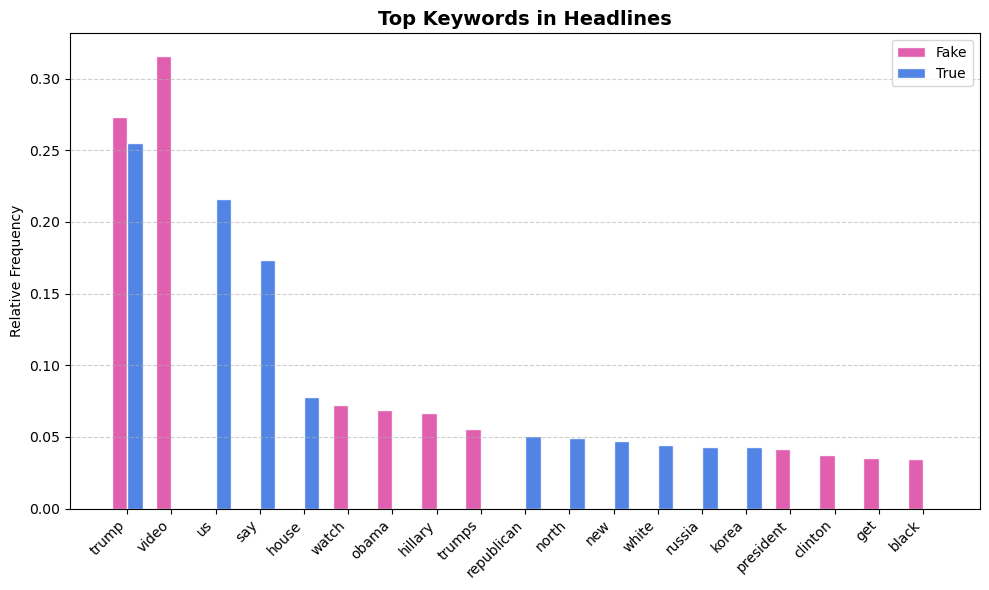

In [24]:
# extracting top 10 words from fake news headlines
fake_title_word = word_frequency(df[df["label"] == 0]["title_analysis"], 10)

# extracting top 10 words from real news headlines
true_title_word = word_frequency(df[df["label"] == 1]["title_analysis"], 10)

# plotting the comparative distribution for headline keywords
# using the consistent project color scheme (pink/blue)
plot_word_freq(fake_title_word, true_title_word, "Top Keywords in Headlines")

### Visualizing Top Keywords in the Article Body
We now extend our lexical analysis to the full body of the news articles. Compared to headlines, the article body provides a much larger vocabulary, allowing us to identify the **dominant narratives** and recurring themes that characterize each class.

This step is essential to verify if the model might rely on specific geographic locations or political names (e.g., "Washington", "Trump", "Reuters") to distinguish between classes, which could indicate a thematic bias in the dataset.

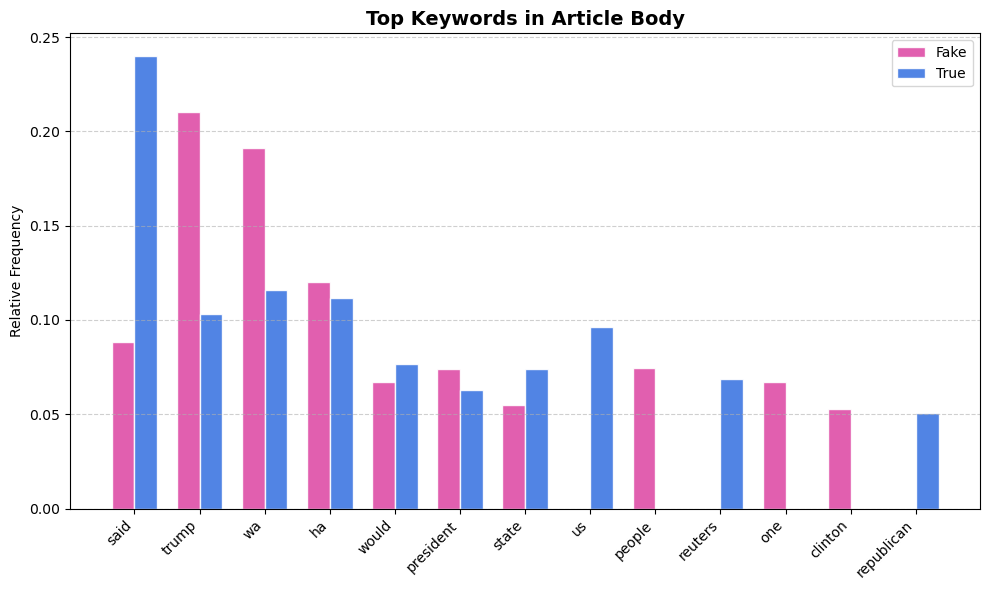

In [25]:
# extracting top 10 words from fake news article bodies
fake_text_word = word_frequency(df[df["label"] == 0]["text_analysis"], 10)

# extracting top 10 words from real news article bodies
true_text_word = word_frequency(df[df["label"] == 1]["text_analysis"], 10)

# plotting the comparative distribution for body text keywords
# analyzing the core thematic differences between the two classes
plot_word_freq(fake_text_word, true_text_word, "Top Keywords in Article Body")

### Structural Analysis: Distribution of Title and Article Lengths
Beyond lexical content, the **physical structure** of a news article (its length in words) can be a strong indicator of its nature. Official reports often follow standardized formats, while misinformation can vary from extremely short "clickbait" snippets to long, rambling narratives.

We use **Boxplots** to compare the two classes, focusing on:
1. **Median Length**: To identify the typical word count for each category.
2. **Interquartile Range (IQR)**: To visualize the consistency or variability in writing styles.
3. **Outliers**: To detect unusually short or long articles that might represent edge cases in the dataset.

### Feature Engineering: Word Count Extraction
To quantify the structural differences between the two classes, we calculate the **Word Count (WC)** for both titles and article bodies. 

This metric allows us to evaluate if there is a statistically significant difference in length between Fake and Real news. For instance, verified news often follows a more consistent length due to editorial standards, while fake news may exhibit more extreme variations (very short clickbait or unusually long emotional narratives).

In [26]:
# word count for each title and text: split separates words by whitespace
# str.len() then counts the number of elements in the resulting list
df["title_wc"] = df["title"].str.split().str.len()
df["text_wc"] = df["text"].str.split().str.len()

# verifying the new features
# checking the first few rows to ensure correct word count calculation

### Structural Insights: Title Word Count Distribution
We visualize the distribution of title lengths to determine if the word count serves as a discriminative feature between the two classes. 

Using **Boxplots** allows us to quickly compare the central tendency (median) and the spread of the data. This visualization is particularly useful for identifying the presence of **statistical outliers**—headlines that are unusually long or short—which often characterize different editorial styles or "clickbait" strategies.

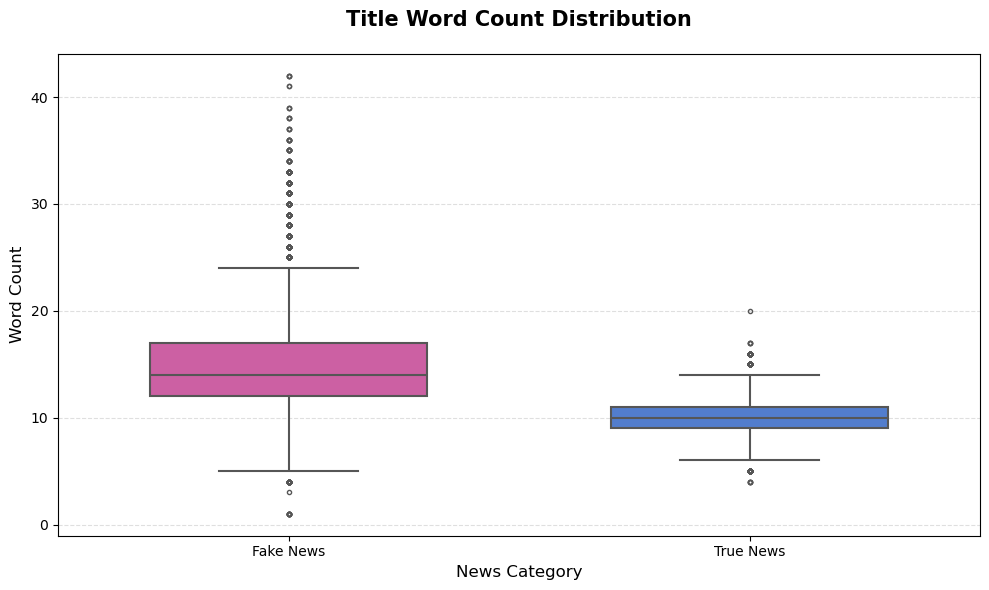

In [27]:
# 1. figure setup
plt.figure(figsize=(10, 6))

# 2. boxplot creation with seaborn
# using 'fliersize' to manage the visibility of outlier points
ax = sns.boxplot(x='label', y='title_wc', data=df, 
                 palette={0: "#de4ea7", 1: "#3e77e1"}, 
                 hue='label', legend=False,
                 width=0.6, linewidth=1.5, fliersize=3)

# 3. aesthetic refinements and labels
# using international titles for the portfolio
plt.title('Title Word Count Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.xticks([0, 1], ['Fake News', 'True News'])

# 4. clean look: removing unnecessary spines and adding a grid
plt.grid(axis='y', linestyle='--', alpha=0.4) # horizontal grid for better readability

plt.tight_layout()
plt.show()

### Structural Insights: Article Body Word Count Distribution
We now extend the structural analysis to the full body of the articles. While titles are constrained by readability, the length of the main text can vary significantly. 

Comparing the **Interquartile Range (IQR)** and the density of outliers helps us understand if "True News" follows a more consistent editorial length (typical of news agencies like Reuters) compared to the higher variance often found in "Fake News" sources.

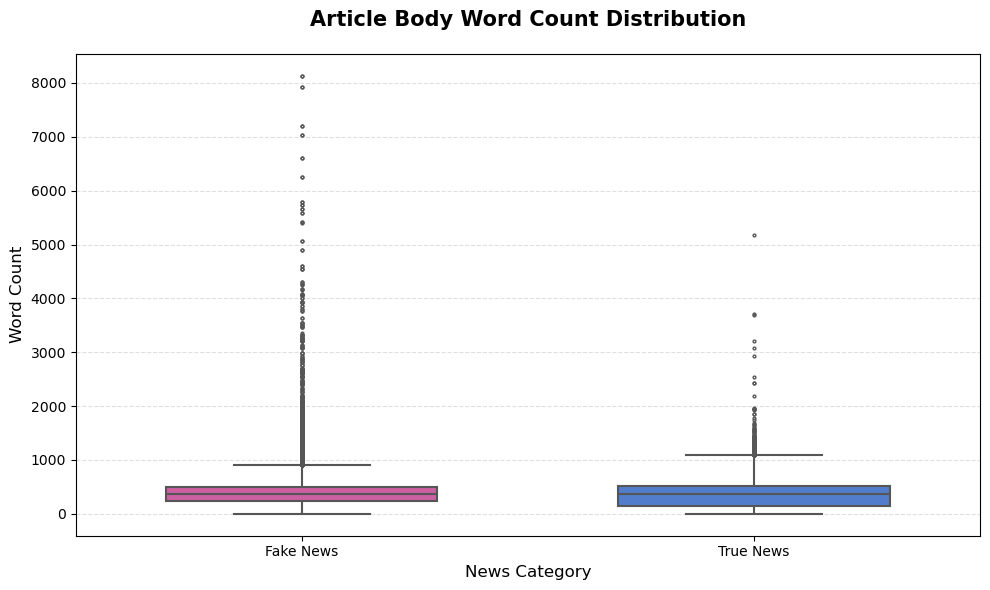

In [28]:
# 1. figure setup
plt.figure(figsize=(10, 6))

# 2. boxplot creation
# using fliersize=2 because with large datasets, outliers (dots) 
# can clutter the plot if they are too large
ax = sns.boxplot(x='label', y='text_wc', data=df, 
                 palette={0: "#de4ea7", 1: "#3e77e1"}, 
                 hue='label', legend=False,
                 width=0.6, linewidth=1.5, fliersize=2)

# 3. professional titles and labels
plt.title('Article Body Word Count Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.xticks([0, 1], ['Fake News', 'True News'])

# 4. axis optimization
# long articles can act as extreme outliers, compressing the main box.
# if needed, we can limit the y-axis to focus on the core distribution:
# plt.ylim(0, 2000) 

# 5. look & feel
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Vectorization and Classification Algorithms
In this section, we transform the processed text into numerical features and evaluate several machine learning architectures. Our goal is to compare different approaches—from traditional tree-based models to boosting techniques and neural networks—to identify the most robust classifier for fake news detection.

The following algorithms are implemented and benchmarked:
- **Decision Tree Classifier**: Comparing a fully grown tree versus a pruned tree with limited depth to manage overfitting.
- **Bagging (Bootstrap Aggregating)**: An ensemble method designed to reduce variance.
- **Random Forest**: A robust ensemble technique using multiple decision trees.
- **XGBoost**: A state-of-the-art gradient boosting framework known for high performance.
- **Support Vector Classifier (SVC)**: Effective for high-dimensional text data.
- **Multilayer Perceptron (MLP)**: Deep learning approaches featuring both single and dual-layer architectures.

### Feature Selection and Target Definition
In this step, we isolate the independent variables (Features) from the dependent variable (Target). 

For the analysis, we use the **concatenated text** (Title + Body) as our primary feature. This combined representation ensures that the model captures linguistic patterns from both the headline's "hook" and the detailed narrative, providing a comprehensive context for truthfulness prediction.

In [29]:
# identifying features and target
X = df["processed"]
y = df["label"]

# checking the shape of the data before vectorization
print(f"Feature shape: {x.shape}")
print(f"Target shape: {y.shape}")

Feature shape: ()
Target shape: (44689,)


In [30]:
# train set size = 75%, test set size = 25%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y) # stratyfy=y for a balanced split between classes (true/false)

### Text Vectorization: TF-IDF Transformation
To enable machine learning, we convert raw text into a numerical format using the **Term Frequency-Inverse Document Frequency (TF-IDF)** weighting scheme. 

Unlike simple word counting, TF-IDF reflects how important a word is to a document in a collection. It assigns higher weights to terms that are frequent in a specific article but rare across the entire dataset, effectively filtering out common language and highlighting **discriminative keywords** that characterize fake or real news. The result is a high-dimensional **sparse matrix** ready for classification.

In [31]:
# initializing the tf-idf vectorizer with custom constraints
tfidf = TfidfVectorizer(
    # token_pattern = r'(?u)\w+|[^\w\s]', # option to keep punctuation as separate tokens (skip preprocessing)
    lowercase=False, # lowercasing already handled in preprocessing
    max_features=1000, # keeping only the most significant features
    max_df=0.5, # ignoring terms appearing in more than 50% of documents
    ngram_range=(1,2) # capturing both single words and pairs (unigrams/bigrams)
)

# transforming the training data and applying the same vocabulary to the test set
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) # note: we only fit on the training set to prevent data leakage from the test set

### Vocabulary sanity check
We extract a random sample of the **1,000 TF-IDF features** to verify the quality of the preprocessing and ensure the vocabulary contains meaningful terms and n-grams for classification.

In [32]:
# extracting feature names from the tf-idf vectorizer
features = pd.DataFrame(tfidf.get_feature_names_out(), columns=['word'])

# shuffling for a random inspection (reproducible via random_state)
features = features.sample(frac=1, random_state=42).reset_index(drop=True)

# printing the first 10 sampled features
for f in features['word'][:10]:
    print(f)

many
request
respect
powerful
in
prison
part
made
syrian
call


### Feature-Weight Mapping
To visualize the numerical representation of our data, we display a sample of the **TF-IDF weights**. This highlights how the vectorizer assigns importance to specific terms within an article, converting linguistic patterns into a high-dimensional feature matrix.

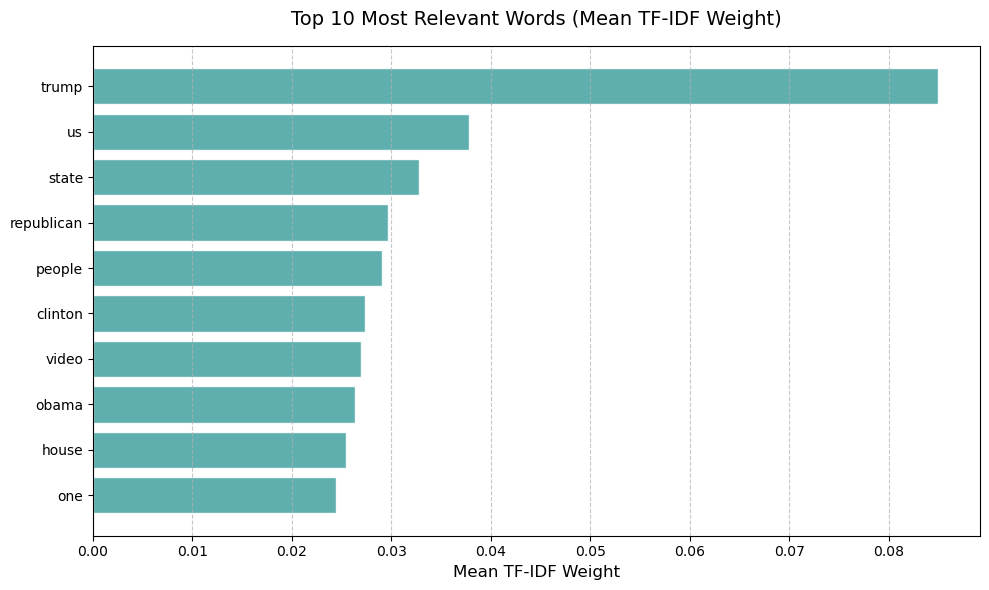

In [33]:
# calculating mean tf-idf weight for each feature
weights = X_train_tfidf.mean(axis=0).tolist()[0]
features = tfidf.get_feature_names_out()

# dataframe creation and sorting
weights_df = pd.DataFrame({'word': features, 'weight': weights})
weights_df = weights_df.sort_values(by='weight', ascending=False)

# selecting top 10 and reversing for horizontal bar chart display
top_10 = weights_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
# using teal for feature importance
plt.barh(top_10['word'], top_10['weight'], color='#4da6a6', edgecolor='white', alpha=0.9)

# styling and labels
plt.title('Top 10 Most Relevant Words (Mean TF-IDF Weight)', fontsize=14, pad=15)
plt.xlabel('Mean TF-IDF Weight', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Model Evaluation Framework
To ensure a rigorous comparison between different architectures, we implement a centralized evaluation function. This utility calculates key performance indicators: **Accuracy**, **Precision**, **Recall**, and the **F1-Score**. 

By storing these results along with **execution times** and **Confusion Matrices** in a global dictionary, we can perform a final benchmarking analysis to identify the optimal balance between predictive power and computational efficiency.

In [45]:
# dictionary to store and compare model performances
model_stats = {} 

# utility function to print and log classification metrics
def print_metrics(y_true, y_pred, model_name, exec_time, save_results):
    print(f"*** {model_name} ***")
    
    # accuracy: overall correctness
    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {acc*100:.2f}%')
    
    # precision: ability to avoid false positives
    prec = precision_score(y_true, y_pred)
    print(f'Precision: {prec*100:.2f}%')
    
    # recall: ability to find all true cases
    recall = recall_score(y_true, y_pred)
    print(f'Recall: {recall*100:.2f}%')
    
    # f1-score: harmonic mean of precision and recall
    f1 = f1_score(y_true, y_pred)
    print(f"F1-score: {f1*100:.2f}%")
    
    # confusion matrix for error analysis
    cm = confusion_matrix(y_true, y_pred)
    print(f'Confusion Matrix:\n{cm}')
    print(f'Execution Time: {exec_time:.1f} seconds')
    print("")
    
    # conditional saving to the global dictionary
    # useful to avoid logging training data or minor variations
    if save_results == 1:
        model_stats[model_name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': recall,
            'F1-Score': f1,
            'Time': exec_time,
            'Matrix': cm
        }

## Model Optimization Strategy: GridSearchCV
To ensure each algorithm performs at its best, we implement a **Systematic Hyperparameter Tuning** strategy using `GridSearchCV`. 

Given the high dimensionality of the TF-IDF feature matrix and the significant size of the dataset, we balance computational efficiency with model refinement. For each classifier, we define a search space for key parameters and use **Cross-Validation (CV)** to select the configuration that offers the best trade-off between accuracy and generalization, minimizing the risk of overfitting.

### Baseline Model: Decision Tree Classifier
We begin our benchmarking with a **Decision Tree Classifier**. As a non-parametric model, it is particularly useful for establishing a performance baseline and understanding how well individual features can split the data classes. 

To refine the model, we tune the following parameters:
- `max_depth`: To control the vertical growth of the tree.
- `ccp_alpha`: Applying **Cost Complexity Pruning** to eliminate branches that do not significantly improve predictive power, effectively simplifying the model for better real-world performance.

In [46]:
# defining the hyperparameter grid for cost complexity pruning
# ccp_alpha: small values prune branches with low predictive power
param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'ccp_alpha': [0.0, 0.001, 0.01], # 0.0 represents the unpruned tree
    'criterion': ['gini']
}

# gridsearchcv setup with 3-fold cross-validation
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training the grid search
start = time.time()
grid_search_dt.fit(X_train_tfidf, y_train)
total_time = time.time() - start

# extracting best parameters and estimator
print(f"Best parameters: {grid_search_dt.best_params_}")
best_dt = grid_search_dt.best_estimator_

# predictions on both sets to check for overfitting
y_pred_train_dt = best_dt.predict(X_train_tfidf)
y_pred_test_dt = best_dt.predict(X_test_tfidf)

# metrics logging
# dynamic label to identify the specific tuned model in our stats
params = grid_search_dt.best_params_
dt_label = f"DT (depth={params['max_depth']}, ccp={params['ccp_alpha']})"

# printing train metrics (save=0) and test metrics (save=1)
print_metrics(y_train, y_pred_train_dt, f"{dt_label} train", total_time, 0)
print_metrics(y_test, y_pred_test_dt, f"{dt_label}", total_time, 1)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None}
*** DT (depth=None, ccp=0.0) train ***
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-score: 100.00%
Confusion Matrix:
[[17608     0]
 [    0 15908]]
Execution Time: 127.0 seconds

*** DT (depth=None, ccp=0.0) ***
Accuracy: 94.26%
Precision: 95.02%
Recall: 92.78%
F1-score: 93.88%
Confusion Matrix:
[[5612  258]
 [ 383 4920]]
Execution Time: 127.0 seconds



### Computational Efficiency: Bagging Light Implementation
To handle the dataset size while maintaining the ensemble approach, we implement an **optimized Bagging strategy**. 

By restricting the `max_samples` to 10-25% of the total training data and limiting the `max_depth` of the base estimators, we significantly reduce the computational overhead. This "Light" configuration allows us to benefit from the **variance reduction** of bagging while ensuring that the execution time remains scalable for a single-machine environment.

In [47]:
# defining a minimized search grid
# limiting estimators and depth to prevent excessive execution times
param_grid_bag = {
    'n_estimators': [20, 50],          # reduced number of trees
    'max_samples': [0.1, 0.25],        # using only 10% or 25% of data per tree
    'estimator__max_depth': [10]       # fixed depth to control complexity
}

# gridsearchcv setup
grid_search_bag = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        bootstrap=True,
        random_state=42,
        n_jobs=-1  # leveraging multi-core processing
    ),
    param_grid=param_grid_bag,
    cv=3,
    scoring='accuracy',
    n_jobs=-1, 
    verbose=1
)

# training phase
start = time.time()
grid_search_bag.fit(X_train_tfidf, y_train)
total_time = time.time() - start

# results extraction
print(f"Best parameters: {grid_search_bag.best_params_}")
best_bag = grid_search_bag.best_estimator_

# predictions for train/test comparison
y_pred_train_bag = best_bag.predict(X_train_tfidf)
y_pred_test_bag = best_bag.predict(X_test_tfidf)

# metrics logging
# dynamic label including max_samples for performance tracking
params = grid_search_bag.best_params_
bag_label = f"Bagging Light (n={params['n_estimators']}, samples={params['max_samples']})"

# printing train results (save=0) and test results (save=1)
print_metrics(y_train, y_pred_train_bag, f"{bag_label} train", total_time, 0)
print_metrics(y_test, y_pred_test_bag, f"{bag_label}", total_time, 1)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'estimator__max_depth': 10, 'max_samples': 0.25, 'n_estimators': 50}
*** Bagging Light (n=50, samples=0.25) train ***
Accuracy: 93.26%
Precision: 90.75%
Recall: 95.54%
F1-score: 93.09%
Confusion Matrix:
[[16059  1549]
 [  709 15199]]
Execution Time: 109.8 seconds

*** Bagging Light (n=50, samples=0.25) ***
Accuracy: 92.80%
Precision: 90.39%
Recall: 94.93%
F1-score: 92.60%
Confusion Matrix:
[[5335  535]
 [ 269 5034]]
Execution Time: 109.8 seconds



### Random Forest: Feature Subsampling and Regularization
To improve upon the bagging approach, we implement a **Random Forest Classifier**. This algorithm introduces "feature randomness" by selecting a random subset of features for each split, which helps in creating less correlated trees. 

In this "Light" version, we apply strict **regularization** by limiting the `max_depth` and increasing the `min_samples_leaf`. This prevents the model from growing overly complex branches that would only capture training-specific noise, thereby ensuring better stability when predicting unseen news articles.

In [48]:
# defining a light and regularized parameter grid to optimize training speed
# limiting depth and enforcing a minimum number of samples per leaf to prevent overfitting
param_grid_rf = {
    'n_estimators': [50, 100],           # fewer trees to balance performance and execution time
    'max_depth': [5, 10, 15],            # explicit depth limits to control model complexity
    'min_samples_leaf': [5, 10],         # ensures leaves are representative of more than just a few samples
    'max_features': ['sqrt']             # using square root of total features for each split to decorrelate trees
}

# configuring gridsearchcv with 3-fold cross-validation for efficient hyperparameter tuning
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3,                                
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training the forest and tracking the total execution time
start = time.time()
grid_search_rf.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# extracting the best estimator and the corresponding optimal parameters
print(f"Best parameters: {grid_search_rf.best_params_}")
best_rf = grid_search_rf.best_estimator_

# generating predictions for both sets to monitor the gap between training and test performance
y_pred_train_rf = best_rf.predict(X_train_tfidf)
y_pred_test_rf = best_rf.predict(X_test_tfidf)

# logging metrics with a dynamic label to identify the specific configuration in final reports
rf_label = f"RF Light (depth={grid_search_rf.best_params_['max_depth']})"
print_metrics(y_train, y_pred_train_rf, f"{rf_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_rf, f"{rf_label}", tempo_totale, 1)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
*** RF Light (depth=15) train ***
Accuracy: 98.21%
Precision: 97.57%
Recall: 98.69%
F1-score: 98.13%
Confusion Matrix:
[[17217   391]
 [  208 15700]]
Execution Time: 134.7 seconds

*** RF Light (depth=15) ***
Accuracy: 97.14%
Precision: 96.25%
Recall: 97.77%
F1-score: 97.01%
Confusion Matrix:
[[5668  202]
 [ 118 5185]]
Execution Time: 134.7 seconds



### Gradient Boosting: XGBoost Implementation
**XGBoost (Extreme Gradient Boosting)** represents the state-of-the-art in ensemble learning. Unlike Random Forest, it builds trees sequentially, where each new model is designed to correct the residual errors of its predecessors.

To achieve a balanced and efficient architecture, we optimize the following:
- **N-Estimators**: We test the number of sequential trees to find the point where the model stops learning new patterns and begins to memorize noise.
- **Learning Rate**: We use a controlled step size to prevent the model from overshooting the optimal solution, ensuring a stable convergence.
- **Max Depth**: Keeping trees shallow (3 to 5 levels) ensures the boosting process remains lightweight and less prone to overfitting the high-dimensional TF-IDF space.
- **Subsampling**: We train each tree on a random 80% subset of the data to increase the model's robustness against outliers.

In [49]:
# defining the parameter grid to balance learning speed and model complexity
# lower learning rates and shallow trees are preferred for better generalization
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.2], # controlled step size to prevent overfitting
    'max_depth': [3, 5],         # shallow trees keep the boosting process efficient
    'subsample': [0.8]           # training on random subsets to increase model stability
}

# setting up gridsearchcv with the binary logistic objective for classification
grid_search_xgb = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training the booster and measuring the total execution time
start = time.time()
grid_search_xgb.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# identifying the optimal configuration from the search results
print(f"Best parameters: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_

# generating predictions to evaluate consistency across train and test sets
y_pred_train_xgb = best_xgb.predict(X_train_tfidf)
y_pred_test_xgb = best_xgb.predict(X_test_tfidf)

# logging metrics with a specific tag for the final benchmarking comparison
xgb_label = f"XGB (lr={grid_search_xgb.best_params_['learning_rate']}, depth={grid_search_xgb.best_params_['max_depth']})"
print_metrics(y_train, y_pred_train_xgb, f"{xgb_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_xgb, f"{xgb_label}", tempo_totale, 1)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
*** XGB (lr=0.2, depth=5) train ***
Accuracy: 99.45%
Precision: 99.29%
Recall: 99.54%
F1-score: 99.42%
Confusion Matrix:
[[17495   113]
 [   73 15835]]
Execution Time: 80.9 seconds

*** XGB (lr=0.2, depth=5) ***
Accuracy: 98.42%
Precision: 98.05%
Recall: 98.64%
F1-score: 98.35%
Confusion Matrix:
[[5766  104]
 [  72 5231]]
Execution Time: 80.9 seconds



### Linear Support Vector Classifier (SVC)
The **Linear Support Vector Classifier** is a powerful tool for text classification. Unlike tree-based ensembles, SVC attempts to find the optimal **hyperplane** that maximizes the margin between "Fake" and "Real" news in the high-dimensional TF-IDF vector space.

For this model, we tune:
- **Regularization (C)**: This parameter controls the trade-off between maximizing the margin and minimizing classification errors. A smaller **C** promotes a simpler model (higher regularization), while a larger **C** aims for better classification on the training set.
- **Penalty (L1 vs L2)**: We test different regularization types to see if the model benefits from sparsity (L1) or a more distributed weight assignment (L2).

In [50]:
# defining the hyperparameter grid to test regularization strength and penalty types
# testing different C values to find the best balance between margin and error
param_grid_svc = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

# setting up gridsearchcv with linearsvc
# dual=False is preferred when the number of samples is greater than the number of features
grid_search_svc = GridSearchCV(
    LinearSVC(random_state=42, max_iter=2000, dual=False), # increased iterations to ensure convergence
    param_grid=param_grid_svc,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training the classifier and measuring execution time
start = time.time()
grid_search_svc.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# identifying the optimal configuration
print(f"Best parameters: {grid_search_svc.best_params_}")
best_svc = grid_search_svc.best_estimator_

# predicting on both sets to evaluate the impact of regularization
y_pred_train_svc = best_svc.predict(X_train_tfidf)
y_pred_test_svc = best_svc.predict(X_test_tfidf)

# logging results with specific parameters for the final comparison table
params = grid_search_svc.best_params_
svc_label = f"LinearSVC (C={params['C']}, penalty={params['penalty']})"

print_metrics(y_train, y_pred_train_svc, f"{svc_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_svc, f"{svc_label}", tempo_totale, 1)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'C': 1, 'penalty': 'l1'}
*** LinearSVC (C=1, penalty=l1) train ***
Accuracy: 98.76%
Precision: 98.61%
Recall: 98.77%
F1-score: 98.69%
Confusion Matrix:
[[17386   222]
 [  195 15713]]
Execution Time: 23.6 seconds

*** LinearSVC (C=1, penalty=l1) ***
Accuracy: 98.18%
Precision: 97.81%
Recall: 98.38%
F1-score: 98.09%
Confusion Matrix:
[[5753  117]
 [  86 5217]]
Execution Time: 23.6 seconds



### Neural Networks: Multilayer Perceptron (MLP)
The final model in our benchmark is the **Multilayer Perceptron (MLP)**. To find the optimal neural architecture, we perform a grid search over different depths and widths:
- **Single-layer**: Testing 16 and 32 neurons to capture direct feature relationships.
- **Dual-layer**: Testing a (32, 16) bottleneck architecture to identify more complex, non-linear patterns in the TF-IDF space.

To ensure efficient training on a single machine, we implement **Early Stopping**, which terminates the process once the validation loss plateaus, and use **L2 Regularization (Alpha)** to maintain weight stability and prevent overfitting.

In [51]:
# defining a consolidated parameter grid for single and dual-layer architectures
# testing different hidden layer configurations, regularization strengths, and learning rates
param_grid_mlp = {
    'hidden_layer_sizes': [(16,), (32,), (32, 16)], 
    'alpha': [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01] 
}

# configuring gridsearchcv with early stopping to optimize training time
# using a 10% internal validation fraction to trigger the stopping mechanism
grid_search_mlp = GridSearchCV(
    MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=50,             # capping epochs to ensure predictable execution time
        early_stopping=True,     # halting training when validation performance stabilizes
        validation_fraction=0.1, 
        random_state=42
    ),
    param_grid=param_grid_mlp,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training the neural network architectures
start = time.time()
grid_search_mlp.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# extracting the best performing estimator and parameters
print(f"Best parameters: {grid_search_mlp.best_params_}")
best_mlp = grid_search_mlp.best_estimator_

# generating predictions for both sets to monitor generalization
y_pred_train_mlp = best_mlp.predict(X_train_tfidf)
y_pred_test_mlp = best_mlp.predict(X_test_tfidf)

# logging metrics with a dynamic label for final benchmarking
params = grid_search_mlp.best_params_
mlp_label = f"MLP (layers={params['hidden_layer_sizes']}, lr={params['learning_rate_init']})"

print_metrics(y_train, y_pred_train_mlp, f"{mlp_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_mlp, f"{mlp_label}", tempo_totale, 1)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01}
*** MLP (layers=(32,), lr=0.01) train ***
Accuracy: 99.59%
Precision: 99.54%
Recall: 99.60%
F1-score: 99.57%
Confusion Matrix:
[[17535    73]
 [   63 15845]]
Execution Time: 52.6 seconds

*** MLP (layers=(32,), lr=0.01) ***
Accuracy: 98.41%
Precision: 98.43%
Recall: 98.21%
F1-score: 98.32%
Confusion Matrix:
[[5787   83]
 [  95 5208]]
Execution Time: 52.6 seconds



## Performance Analysis and Model Comparison
In this final stage, we aggregate the results of all tested architectures to identify the most effective classifier for fake news detection. Our evaluation goes beyond simple **Accuracy**; we analyze the **Precision-Recall trade-off** and the **F1-Score** to ensure the model handles both classes reliably. 

Furthermore, we consider **Execution Time** as a key factor for scalability. By visualizing the **Confusion Matrices**, we can pinpoint which models are more prone to specific errors, such as misclassifying a deceptive article as truthful (False Negative), which is critical in the context of misinformation.

In [52]:
# preparing the data for visualization (to be executed once)
# sorting the dataframe by accuracy to create a clear performance ranking
df_stats = pd.DataFrame(model_stats).T.sort_values(by='Accuracy', ascending=False)

# defining the labels and positions for the bar chart axes
models = df_stats.index
x = np.arange(len(models)) # the label locations
width = 0.35               # the width of the bars

# logging the sorted benchmark for a quick numerical check
print("Models ranked by Accuracy:")
print(df_stats['Accuracy'])

Models ranked by Accuracy:
XGB (lr=0.2, depth=5)                 0.984248
MLP (layers=(32,), lr=0.01)           0.984069
LinearSVC (C=1, penalty=l1)           0.981831
RF Light (depth=15)                    0.97136
DT (depth=None, ccp=0.0)               0.94263
Bagging Light (n=50, samples=0.25)    0.928041
Name: Accuracy, dtype: object


### Visual Comparison: Accuracy vs. F1-Score
To finalize our analysis, we compare the **Accuracy** and **F1-Score** of all models. While accuracy provides a general measure of performance, the F1-Score ensures that the model maintains a balance between Precision and Recall.

By adjusting the y-axis limits (**0.85 to 1.0**), we can effectively visualize the marginal gains achieved by more complex models compared to our baseline. This "zoomed" perspective is essential for identifying the most robust classifier in high-performing scenarios.

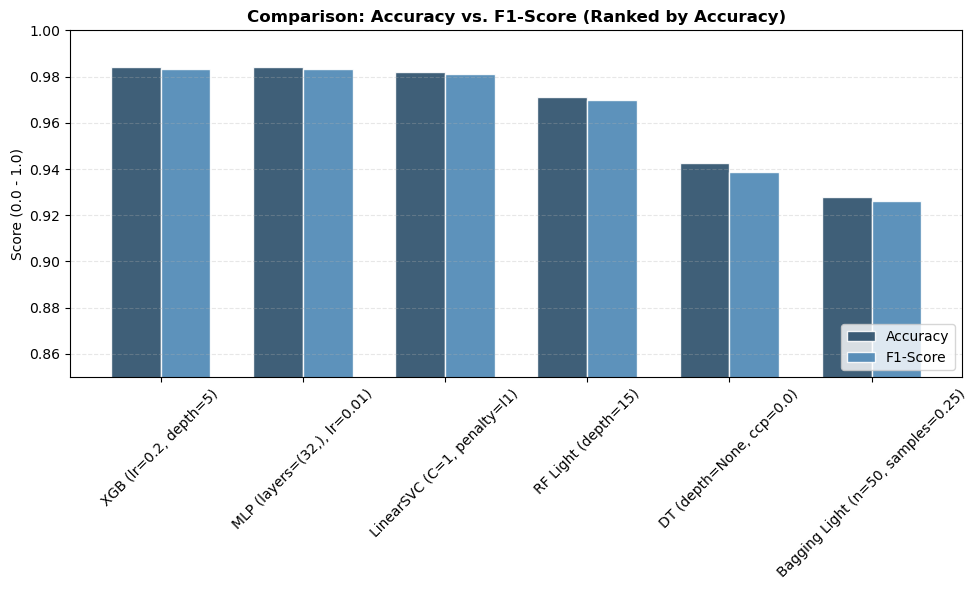

In [53]:
plt.figure(figsize=(10, 6))

# plotting accuracy and f1-score side by side for each model
# using a professional color palette to distinguish the two metrics
plt.bar(x - width/2, df_stats['Accuracy'], width, label='Accuracy', color='#2a4d69', edgecolor='white', alpha=0.9)
plt.bar(x + width/2, df_stats['F1-Score'], width, label='F1-Score', color='#4b86b4', edgecolor='white', alpha=0.9)

# chart styling and labeling
plt.title('Comparison: Accuracy vs. F1-Score (Ranked by Accuracy)', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(x, models, rotation=45)

# zooming in on the 0.85-1.0 range to highlight performance differences
plt.ylim(0.85, 1.0) 
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Precision vs. Recall Trade-off
To better understand the behavior of our classifiers, we compare **Precision** and **Recall**. In a misinformation context:
- **High Precision** ensures that when the model flags a news item as fake, it is highly likely to be correct (minimizing "False Alarms").
- **High Recall** ensures that the model captures most of the deceptive content (minimizing "Missed Detections").

Analyzing these metrics side-by-side allows us to evaluate the reliability of each model and choose the one that best aligns with our specific risk-tolerance for misclassification.

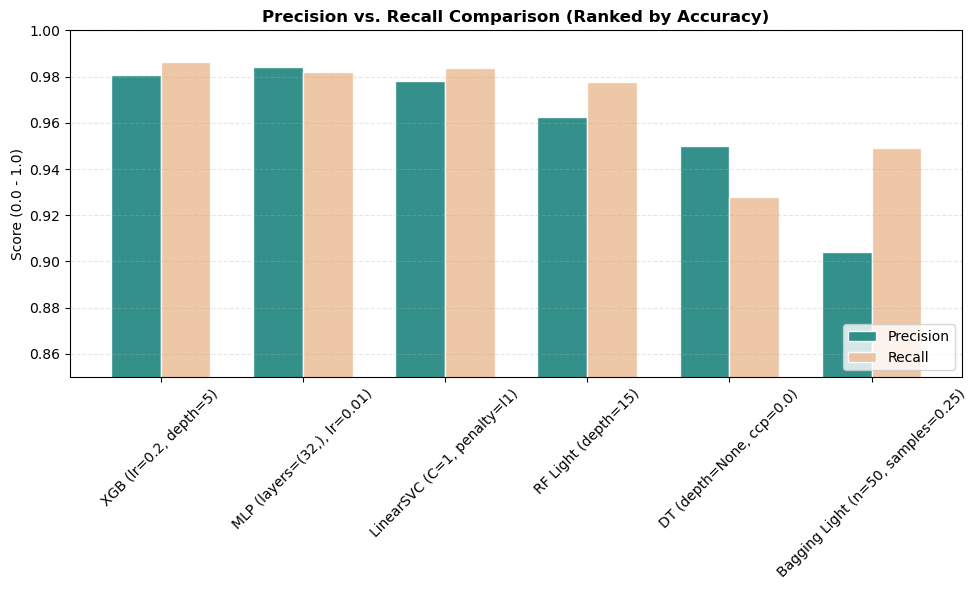

In [54]:
plt.figure(figsize=(10, 6))

# plotting precision and recall to evaluate the trade-off for each classifier
# using a contrasting teal and sand palette for visual clarity
plt.bar(x - width/2, df_stats['Precision'], width, label='Precision', color='#1e847f', edgecolor='white', alpha=0.9)
plt.bar(x + width/2, df_stats['Recall'], width, label='Recall', color='#ecc19c', edgecolor='white', alpha=0.9)

# styling and labeling to match the previous performance chart
plt.title('Precision vs. Recall Comparison (Ranked by Accuracy)', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(x, models, rotation=45)

# maintaining a consistent zoom level (0.85 - 1.0) to highlight subtle variations
plt.ylim(0.85, 1.0) 
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Computational Efficiency: Training and Tuning Time
In a production environment, the trade-off between predictive performance and **computational cost** is a key decision factor. This final visualization compares the total time required for training and hyperparameter tuning across all models. 

By analyzing execution times, we can identify which architectures offer the best "return on investment"—achieving high accuracy while maintaining scalability for large-scale data processing or real-time news analysis.

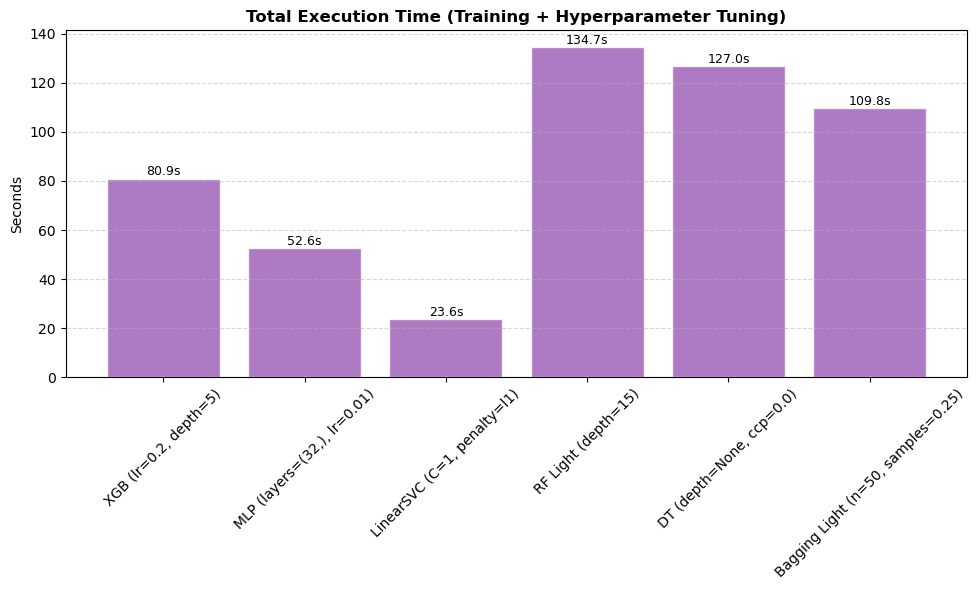

In [55]:
plt.figure(figsize=(10, 6))

# using a distinct purple hue to differentiate execution time from performance metrics
plt.bar(models, df_stats['Time'], color='#9b59b6', alpha=0.8, edgecolor='white')

# chart styling and axis labeling
plt.title('Total Execution Time (Training + Hyperparameter Tuning)', fontweight='bold')
plt.ylabel('Seconds')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# adding data labels above the bars for immediate readability
# displaying time in seconds with one decimal precision
for i, v in enumerate(df_stats['Time']):
    plt.text(i, v + 0.1, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Error Analysis: Normalized Confusion Matrix Comparison
To gain deeper insight into model behavior, we visualize the **Confusion Matrix components** (TN, FP, FN, TP) as percentages. By normalizing these values per class, we can directly compare how each model handles the specific challenges of fake news detection.

This visualization is crucial for identifying:
- **Reliability (TN/TP)**: Which models are most consistent in identifying both truthful and deceptive content.
- **Critical Errors (FP/FN)**: Whether a model is more prone to labeling real news as fake (False Positives) or missing deceptive articles entirely (False Negatives), allowing us to select the classifier that best fits our risk-tolerance.

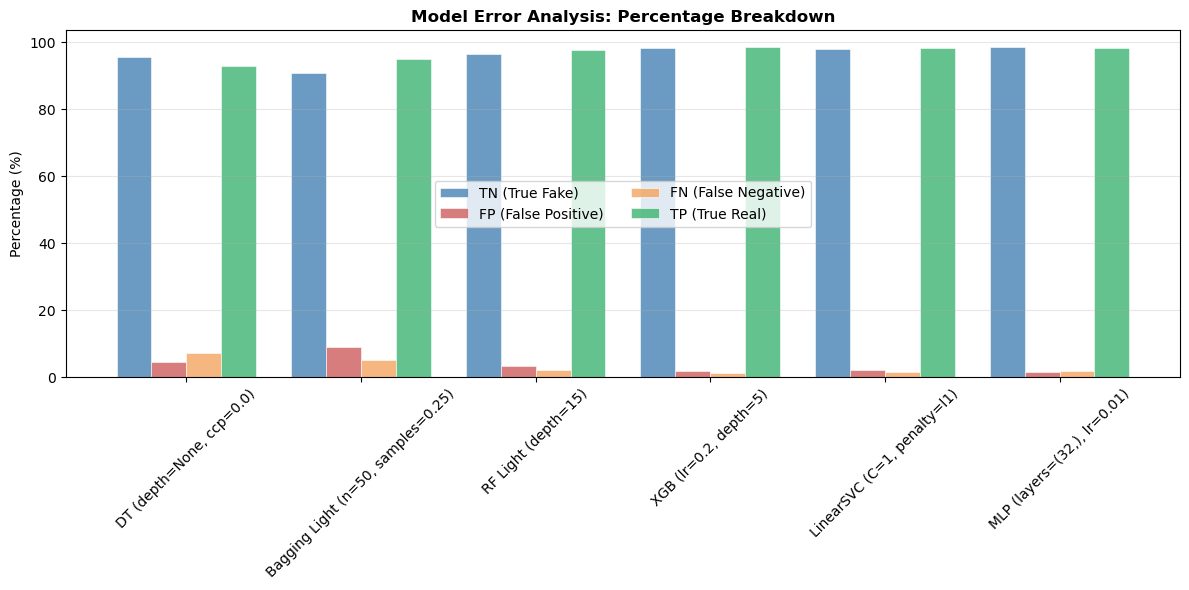

In [56]:
def plot_cm(dict_stats):
    models = list(dict_stats.keys())
    
    # lists to store normalized confusion matrix values
    tn, fp, fn, tp = [], [], [], []

    for m in models:
        cm = dict_stats[m]['Matrix']
        
        # normalizing by row sums to obtain percentages
        row0 = cm[0].sum() # total fake news
        row1 = cm[1].sum() # total real news
        
        # calculating percentages for each quadrant
        tn.append((cm[0,0] / row0) * 100) # true negative (correctly identified fake)
        fp.append((cm[0,1] / row0) * 100) # false positive (real news mislabeled as fake)
        fn.append((cm[1,0] / row1) * 100) # false negative (fake news mislabeled as real)
        tp.append((cm[1,1] / row1) * 100) # true positive (correctly identified real)

    # bar chart configuration
    x = np.arange(len(models))
    width = 0.2 

    plt.figure(figsize=(12, 6))

    # plotting bars with a distinct color palette for error types
    plt.bar(x - 1.5*width, tn, width, label='TN (True Fake)', color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.5)
    plt.bar(x - 0.5*width, fp, width, label='FP (False Positive)', color='indianred', alpha=0.8, edgecolor='white', linewidth=0.5)
    plt.bar(x + 0.5*width, fn, width, label='FN (False Negative)', color='sandybrown', alpha=0.8, edgecolor='white', linewidth=0.5)
    plt.bar(x + 1.5*width, tp, width, label='TP (True Real)', color='mediumseagreen', alpha=0.8, edgecolor='white', linewidth=0.5)

    # chart styling and legend placement
    plt.ylabel('Percentage (%)')
    plt.title('Model Error Analysis: Percentage Breakdown', fontweight='bold')
    plt.xticks(x, models, rotation=45)
    plt.legend(ncol=2, loc='center') # centered legend to keep the upper plot area clear
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# executing the comparison plot
plot_cm(model_stats)

## Final Comparison Matrix: Performance Heatmap
To provide a definitive overview of our experiments, we generate a **Styilzed Performance Matrix**. This heatmap approach allows for immediate identification of the best-performing architectures:

- **Performance Metrics**: Shaded from Yellow to Green, where deep green represents the highest scores in Accuracy, Precision, Recall, and F1-Score.
- **Efficiency (Time)**: Uses an inverted Red-Yellow-Green gradient, where red highlights computationally expensive models and green identifies the most efficient ones.

This table serves as a **decision-support tool** to select the ideal classifier based on the specific constraints of accuracy requirements versus available computational resources.

In [57]:
# preparing the final dataframe by sorting by accuracy
df_final = pd.DataFrame(model_stats).T
df_final = df_final.sort_values(by='Accuracy', ascending=False)

# removing the raw matrix column to keep the table clean and readable
if 'Matrix' in df_final.columns:
    df_final = df_final.drop(columns=['Matrix'])

# defining the performance metrics to be highlighted
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# applying the gradient stylization (Heatmap)
# using 'YlGn' for performance: higher scores appear greener
# using 'RdYlGn_r' for time: lower execution times appear greener (inverted gradient)
final_table_styled = df_final.style.background_gradient(
    subset=performance_metrics, 
    cmap='YlGn', 
    axis=0
).background_gradient(
    subset=['Time'], 
    cmap='RdYlGn_r', 
    axis=0
).format(precision=4)

print("FINAL COMPARATIVE TABLE (Performance Heatmap)")
display(final_table_styled)

FINAL COMPARATIVE TABLE (Performance Heatmap)


,Accuracy,Precision,Recall,F1-Score,Time
"XGB (lr=0.2, depth=5)",0.9842,0.9805,0.9864,0.9835,80.9240
"MLP (layers=(32,), lr=0.01)",0.9841,0.9843,0.9821,0.9832,52.5781
"LinearSVC (C=1, penalty=l1)",0.9818,0.9781,0.9838,0.9809,23.5975
RF Light (depth=15),0.9714,0.9625,0.9777,0.9701,134.7369
"DT (depth=None, ccp=0.0)",0.9426,0.9502,0.9278,0.9388,126.9565
"Bagging Light (n=50, samples=0.25)",0.9280,0.9039,0.9493,0.9260,109.7587
